In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from collections import Counter
import re
import matplotlib.pyplot as plt

In [2]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [6]:
df = pd.read_excel('C:/Codes/Scripts_gen/movies.xlsx')
scripts = df['Sript'].dropna().str.cat(sep=' ')  # Concat all scripts into one corpus

# Preprocess: Clean and tokenize
def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text.lower())  # Remove punctuation, lowercase
    return text.split()

tokens = preprocess_text(scripts)
vocab = ['<PAD>', '<UNK>', '<SOS>', '<EOS>'] + list(set(tokens))  # Build vocab
vocab_size = len(vocab)
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

# Create sequences (e.g., window of 20 words -> predict next)
seq_length = 20
sequences = []
next_words = []
for i in range(len(tokens) - seq_length):
    seq = tokens[i:i+seq_length]
    next_w = tokens[i+seq_length]
    if next_w in word_to_idx:
        sequences.append([word_to_idx[w] for w in seq])
        next_words.append(word_to_idx[next_w])

# Dataset class
class TextDataset(Dataset):
    def __init__(self, sequences, next_words, device):
        self.sequences = torch.tensor(sequences, dtype=torch.long).to(device)
        self.next_words = torch.tensor(next_words, dtype=torch.long).to(device)
        self.device = device
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.next_words[idx]

dataset = TextDataset(sequences, next_words, device)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [21]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_size=100, hidden_size=128, num_layers=2, dropout=0.5, device='cpu'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.device = device
        self.to(device)
    
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        out = self.dropout(out[:, -1, :])  # Last time step
        return self.fc(out), hidden

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_size=100, hidden_size=128, num_layers=2, dropout=0.5, device='cpu'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.device = device
        self.to(device)
    
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.dropout(out[:, -1, :])
        return self.fc(out), hidden

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_size=100, hidden_size=128, num_layers=2, dropout=0.5, device='cpu'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.device = device
        self.to(device)
    
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.gru(x, hidden)
        out = self.dropout(out[:, -1, :])
        return self.fc(out), hidden

# Training function (updated for device)
def train_model(model, dataloader, epochs=20, lr=0.0001, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    start_time = time.time()
    losses = []
    for epoch in range(epochs):
        total_loss = 0
        for seq, next_w in dataloader:
            seq, next_w = seq.to(device), next_w.to(device)  # Ensure on device
            optimizer.zero_grad()
            output, _ = model(seq)
            loss = criterion(output, next_w)
            loss.backward()
            # Gradient clipping for exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')
    training_time = time.time() - start_time
    perplexity = np.exp(avg_loss)  # Lower perplexity = better performance
    return perplexity, training_time, losses

import time

# Instantiate and train models (pass device)
models = {
    'RNN': RNNModel(vocab_size, device=device),
    'LSTM': LSTMModel(vocab_size, device=device),
    'GRU': GRUModel(vocab_size, device=device)
}

results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    perplexity, train_time, losses = train_model(model, dataloader, device=device)
    results[name] = {'perplexity': perplexity, 'time': train_time}

# Compare
print("\nComparison:")
comparison_df = pd.DataFrame(results).T
print(comparison_df)


Training RNN...
Epoch 1/20, Loss: 7.8237
Epoch 2/20, Loss: 7.4575
Epoch 3/20, Loss: 7.3487
Epoch 4/20, Loss: 7.2487
Epoch 5/20, Loss: 7.1651
Epoch 6/20, Loss: 7.0999
Epoch 7/20, Loss: 7.0433
Epoch 8/20, Loss: 6.9962
Epoch 9/20, Loss: 6.9501
Epoch 10/20, Loss: 6.9122
Epoch 11/20, Loss: 6.8725
Epoch 12/20, Loss: 6.8404
Epoch 13/20, Loss: 6.8111
Epoch 14/20, Loss: 6.7799
Epoch 15/20, Loss: 6.7495
Epoch 16/20, Loss: 6.7246
Epoch 17/20, Loss: 6.7019
Epoch 18/20, Loss: 6.6769
Epoch 19/20, Loss: 6.6555
Epoch 20/20, Loss: 6.6353

Training LSTM...
Epoch 1/20, Loss: 7.7177
Epoch 2/20, Loss: 7.4032
Epoch 3/20, Loss: 7.3348
Epoch 4/20, Loss: 7.2625
Epoch 5/20, Loss: 7.1872
Epoch 6/20, Loss: 7.1194
Epoch 7/20, Loss: 7.0606
Epoch 8/20, Loss: 7.0081
Epoch 9/20, Loss: 6.9627
Epoch 10/20, Loss: 6.9183
Epoch 11/20, Loss: 6.8766
Epoch 12/20, Loss: 6.8415
Epoch 13/20, Loss: 6.8093
Epoch 14/20, Loss: 6.7774
Epoch 15/20, Loss: 6.7458
Epoch 16/20, Loss: 6.7222
Epoch 17/20, Loss: 6.6900
Epoch 18/20, Loss: 6.

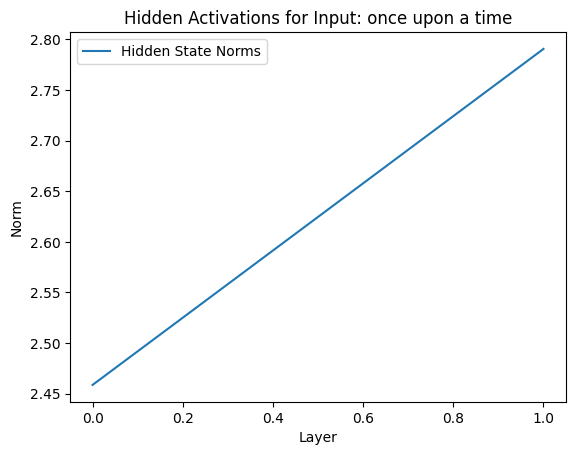

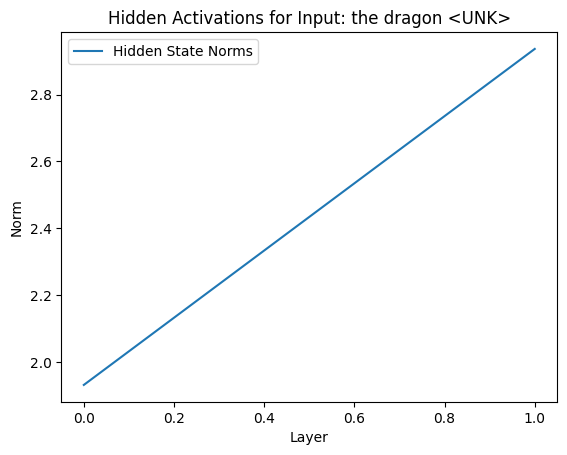

In [22]:
hidden_states = []
def hook_fn(module, input, output):
    hidden = output[1][0].detach().cpu().numpy()  # Move to CPU for visualization
    hidden_states.append(hidden)

# Sample inputs
sample_seqs = [
    [word_to_idx.get('once', 1), word_to_idx.get('upon', 1), word_to_idx.get('a', 1), word_to_idx.get('time', 1)],  # "once upon a time"
    [word_to_idx.get('the', 1), word_to_idx.get('dragon', 1), word_to_idx.get('roared', 1)]  # "the dragon roared"
]
models['LSTM'].lstm.register_forward_hook(hook_fn)

models['LSTM'].eval()
with torch.no_grad():
    for seq in sample_seqs:
        input_tensor = torch.tensor([seq], dtype=torch.long).to(device)
        _, _ = models['LSTM'](input_tensor)
        # Plot norm of hidden states over layers/sequence
        norms = [np.linalg.norm(h) for h in hidden_states[-1]]  # Per layer
        plt.figure()
        plt.plot(norms, label='Hidden State Norms')
        plt.title(f'Hidden Activations for Input: {" ".join([idx_to_word[i] for i in seq])}')
        plt.xlabel('Layer')
        plt.ylabel('Norm')
        plt.legend()
        plt.show()
        hidden_states = []

In [23]:
class AttentionRNN(nn.Module):
    def __init__(self, vocab_size, embed_size=100, hidden_size=128, num_layers=2, dropout=0.5, device='cpu'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        # Attention: query (current hidden), keys/values (previous hiddens)
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.attn_combine = nn.Linear(hidden_size * 2, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.tanh = nn.Tanh()
        self.device = device
        self.to(device)
    
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        rnn_out, hidden = self.rnn(x, hidden)  # (batch, seq, hidden)
        
        # Attention over sequence
        attn_weights = torch.zeros(rnn_out.size(0), rnn_out.size(1), device=self.device)
        for t in range(rnn_out.size(1)):
            # Simplified: attend to all previous
            prev_h = rnn_out[:, :t, :] if t > 0 else torch.zeros_like(rnn_out[:, :1, :]).to(self.device)
            query = rnn_out[:, t:t+1, :]
            attn_input = torch.cat((query.expand(-1, prev_h.size(1), -1), prev_h), dim=-1)
            attn_scores = self.tanh(self.attn(attn_input)).mean(dim=-1)  # (batch, prev_len)
            attn_weights[:, :t] = torch.softmax(attn_scores, dim=-1)
        
        # Weighted context
        context = torch.bmm(attn_weights.unsqueeze(1), rnn_out).squeeze(1)  # (batch, hidden)
        combined = torch.cat((rnn_out[:, -1, :], context), dim=-1)
        combined = self.tanh(self.attn_combine(combined))
        out = self.dropout(combined)
        return self.fc(out), hidden

# Train attention model (reuse train_model function)
attn_model = AttentionRNN(vocab_size, device=device)
perplexity_attn, time_attn, _ = train_model(attn_model, dataloader, device=device)
print(f"Attention RNN Perplexity: {perplexity_attn}, Time: {time_attn}")

Epoch 1/20, Loss: 7.7438
Epoch 2/20, Loss: 7.3958
Epoch 3/20, Loss: 7.2857
Epoch 4/20, Loss: 7.1934
Epoch 5/20, Loss: 7.1205
Epoch 6/20, Loss: 7.0585
Epoch 7/20, Loss: 7.0085
Epoch 8/20, Loss: 6.9609
Epoch 9/20, Loss: 6.9249
Epoch 10/20, Loss: 6.8862
Epoch 11/20, Loss: 6.8521
Epoch 12/20, Loss: 6.8199
Epoch 13/20, Loss: 6.7927
Epoch 14/20, Loss: 6.7608
Epoch 15/20, Loss: 6.7364
Epoch 16/20, Loss: 6.7102
Epoch 17/20, Loss: 6.6859
Epoch 18/20, Loss: 6.6610
Epoch 19/20, Loss: 6.6379
Epoch 20/20, Loss: 6.6163
Attention RNN Perplexity: 747.1832962178382, Time: 595.4038712978363


In [24]:
def generate_text(model, prompt, max_len=50, strategy='topk', k=5, temperature=1.0, device='cpu'):
    model.eval()
    words = preprocess_text(prompt)
    input_seq = torch.tensor([[word_to_idx.get(w, 1) for w in words[-seq_length:]]], dtype=torch.long).to(device)
    generated = words[:]
    hidden = None
    with torch.no_grad():
        for _ in range(max_len):
            output, hidden = model(input_seq, hidden)
            if strategy == 'greedy':
                next_idx = output.argmax(dim=-1).item()
            else:  # Top-k with temperature
                probs = torch.softmax(output / temperature, dim=-1)
                topk_probs, topk_idx = probs.topk(k)
                next_idx = torch.multinomial(topk_probs, 1).item()
                next_idx = topk_idx[0, next_idx].item()
            next_word = idx_to_word.get(next_idx, '<UNK>')
            if next_word == '<EOS>':
                break
            generated.append(next_word)
            input_seq = torch.cat((input_seq[:, 1:], torch.tensor([[next_idx]], dtype=torch.long).to(device)), dim=1)
    return ' '.join(generated)

# Example usage
prompt = "long time ago"
print(generate_text(models['LSTM'], prompt, strategy='topk', device=device))
print(generate_text(models['RNN'], prompt, strategy='topk', device=device))
print(generate_text(models['GRU'], prompt, strategy='topk', device=device))
print(generate_text(attn_model, prompt, strategy='topk', device=device))

long time ago the door are a few of claws and the thing are you you dont have you to be me you i know it to the world i want you you dont do i want you to be you i dont have the world i dont have to get it and
long time ago the man is a little woman and then he is the man of the door of the floor of the room is the room in the air of the door of the other room of the room and is a few woman and then a small of the floor is
long time ago and i think you want to get it i dont know it was a long of the other and is a small very girl in his hand in the door and a little woman is a big girl a small woman with an small red and of the water and
long time ago it up and looks back at her hands the head is in the door of the door the man is the whole thing of the last of the door and is in a small table and the water of the door and a large girl and a small girl of
